In [ ]:
import pandas as pd

df=pd.read_csv(r'/data/combined_dataset.csv', encoding='latin1')

In [2]:
print(df.head())
print(df.shape)
import re

def clean_text(text):
    text = text.lower()

    text = re.sub(r'&\w+;', ' ', text)   # remove &nbsp;
    text = text.replace('_', ' ')        # remove _
    text = re.sub(r'\bnbsp\b', ' ', text) # remove leftover 'nbsp'
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['v2'] = df['v2'].apply(clean_text)

     v1                                                 v2
0  spam  Congratulations! You've been selected for a lu...
1  spam  URGENT: Your account has been compromised. Cli...
2  spam  You've won a free iPhone! Claim your prize by ...
3  spam  Act now and receive a 50% discount on all purc...
4  spam  Important notice: Your subscription will expir...
(16533, 2)


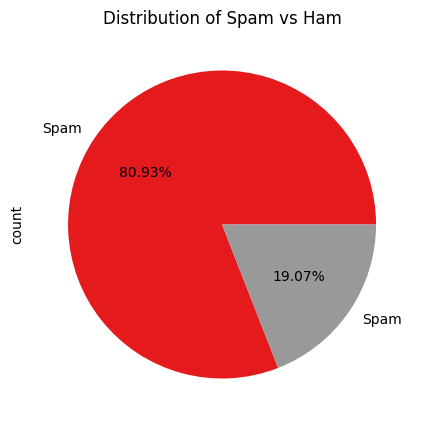

In [4]:
import matplotlib.pyplot as plt


# Chart - 1 Pie Chart Visualization Code For Distribution of Spam vs Ham Messages
spread = df['v1'].value_counts() # Changed from df['v2'] to df['v1']
plt.rcParams['figure.figsize'] = (5,5)

# Set Labels
# Map the numerical labels (0, 1) back to 'Ham', 'Spam' for better readability in the plot
labels = ['Ham' if x == 0 else 'Spam' for x in spread.index]
spread.plot(kind = 'pie', autopct='%1.2f%%', cmap='Set1', labels=labels)
plt.title(f'Distribution of Spam vs Ham')

# Display the Chart
plt.show()

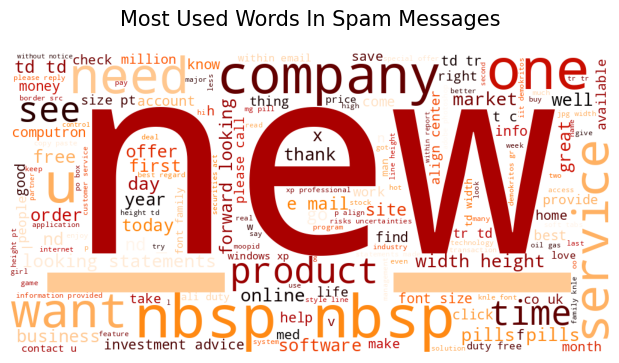

In [7]:
# Chart - 2 WordCloud Plot Visualization Code For Most Used Words in Spam Messages
# Create a String to Store All The Words
# Splitting Spam Messages
df_spam = df[df['v1']=='spam'].copy()

from wordcloud import WordCloud, STOPWORDS
comment_words = ''

# Remove The Stopwords
stopwords = set(STOPWORDS)

# Iterate Through The Column
for val in df_spam.v2:

    # Typecaste Each Val to String
    val = str(val)

    # Split The Value
    tokens = val.split()

    # Converts Each Token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    comment_words += " ".join(tokens)+" "

# Set Parameters
wordcloud = WordCloud(width = 1000, height = 500,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10,
                max_words = 1000,
                colormap = 'gist_heat_r').generate(comment_words)

# Set Labels
plt.figure(figsize = (6,6), facecolor = None)
plt.title('Most Used Words In Spam Messages', fontsize = 15, pad=20)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

# Display Chart
plt.show()

In [ ]:

"""(token)->lowercase->removing stoping words->
->(lemmatization ->)tf-idf->"""
#lower
df['v2']=df['v2'].str.lower()


#removing stoping words

import nltk
from nltk.corpus import stopwords

#running these once is enough but yeah
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))

df['v2'] = df['v2'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)


print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


     v1                                                 v2
0  spam  congratulations! selected luxury vacation geta...
1  spam  urgent: account compromised. click reset passw...
2  spam        free iphone! claim prize clicking link now.
3  spam  act receive 50% discount purchases. limited ti...
4  spam  important notice: subscription expire soon. re...


In [8]:
#lemmatization

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer=WordNetLemmatizer()

df['v2']=df['v2'].apply(
    lambda x:" ".join([lemmatizer.lemmatize(word) for word in x.split()])
)
print(df.head())

[nltk_data] Downloading package wordnet to /root/nltk_data...


     v1                                                 v2
0  spam  congratulations! selected luxury vacation geta...
1  spam  urgent: account compromised. click reset passw...
2  spam        free iphone! claim prize clicking link now.
3  spam  act receive 50% discount purchases. limited ti...
4  spam  important notice: subscription expire soon. re...


In [9]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer()

X=vectorizer.fit_transform(df['v2'])

print(vectorizer.get_feature_names_out())
print(X.toarray())

['00' '000' '0000' ... 'ãº1' 'ã¼' 'ì¼1']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
df['v1'] = df['v1'].map({'ham': 0, 'spam': 1})

y = df['v1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9301481705473239


In [11]:
#ts is a spam message so lets test it
#Get First Access! Join Our WhatsApp Channel for Exclusive Deals, Tech Tips & Latest Launches

def preprocess(text):
    # Lowercasing
    text = text.lower()
    # Removing stop words
    text = " ".join([word for word in text.split() if word not in stop_words])
    # Lemmatization
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split()])
    return text

def predict_message(msg):
    msg_clean = preprocess(msg)


    msg_vec = vectorizer.transform([msg_clean])

    return model.predict(msg_vec)[0]


# Try it
print(predict_message("URGENT: Your bank account has been temporarily suspended. Confirm your identity now to avoid permanent closure: http://secure-update-login.net"))
print(predict_message("Hey bro, are we meeting today?"))

1
0


In [12]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[2696    0]
 [ 231  380]]


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2696
           1       1.00      0.62      0.77       611

    accuracy                           0.93      3307
   macro avg       0.96      0.81      0.86      3307
weighted avg       0.94      0.93      0.92      3307

